<img src="./logo_UTN.svg" align="right" width="150" /> 

# Tarea semanal 0

*Alumno: Lapilli Cañedo, Mariano Adrian*

## Consigna

### Sea el siguiente circuito:

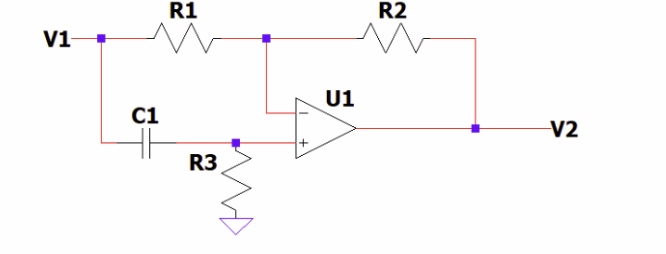

1.  Obtener la función transferencia $\frac{V_1}{V_2}$ :  módulo , fase y diagrama de polos y ceros.  

2.  Proponga una norma de frecuencia e impedancia  de forma tal de llegar a una transferencia normalizada

3.  Simule la transferencia normalizada en Python.

4. Simule la red en LTspice y obtenga su respuesta en frecuencia.

5. ¿ Que tipo de filtro es ? Analizar el caso del MF-103  ¿ Utiliza la misma red ?

Bonus  

+1 💎 Obtener una red normalizada que responda a la función hallada en 2 

+1 💎 Verifique los resultados de 1 y 2 mediante el modulo de simulación simbólica SymPy

+1 💎 Analice similitudes y diferencias con ambas redes del TP1-Ej7 


In [2]:
# Importo librerias de python para trabajar

import numpy as np
from scipy import signal as sig
import sympy as sp
from matplotlib import pyplot as plt
from pytc2.remociones import remover_polo_dc
from pytc2.general import a_equal_b_latex_s, print_latex, s, symbfunc2tf, factorSOS
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys


## Resolución

### Item 1
El ejercicio se reolverá mediante el **Método de Nodos**. En este cicuito tenemos 4 nodos, los cuales serán indicados en la siguiente imagen:
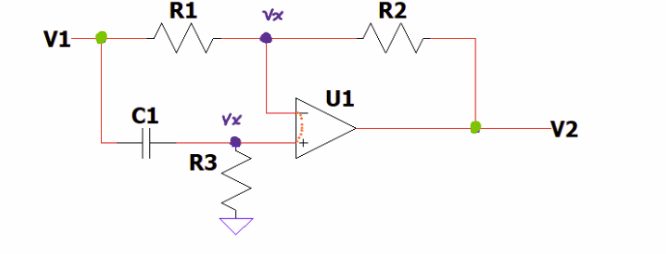 

*Además de los nodos, se marcó la presencia de un cortocircuito virtual entre la pata inversora y no inversora del operacional, por lo que la diferencia de potencial en R3 será **idealmemte** igual a la diferencia de potencial del nodo R1-R2. Yo decidí denominarlo como $V_x$*

Los Nodos V1 y V2 (marcados en verde) no son utilizables, debido a que no podemos determinar a ciencia cierta todas las corrientes que entran y/o salen del mismo2
Una vez aclarado esto, planteo las ecuaciones de nodos quedando de la siguiente manera:

$Nodo \ A:$
$\frac{(V_x - V_1)}{R_1} + \frac{(V_x - V_2)}{R_2} = 0$

$Nodo \ B:$
$\frac{(V_x)}{R_3} + (V_x - V_1) \ sC_1 = 0$

Luego, haciendo uso del álgebra, se consigue llegar a la expresión a la expresión de la transferencia $T(s)$ del circuito dando como resultado:

$$T(s) = \frac{R_2}{R_1} \frac{s C_1 R_3 R_1 - R_2}{s C_1 R_3 R_2 + R_2}$$

En mi caso, y como el enunciado no lo especifíca, decidí imponer como condición que $R_1 = R_2$ dando como resultado: 

$$T(s) = \frac{s C_1 R_3 - 1}{s C_1 R_3 + 1} \rightarrow FILTRO \ PASA \ TODO$$

Para hacer los gráficos de módulo y fase usamos la expresión $T(\omega)$, osea, $T(s) |_{s=j\omega}$. La misma queda definida como:

$$T(\omega) = \frac{j\omega C_1 R_3 - 1}{j\omega C_1 R_3 + 1}$$

Módulo: 

$$|T(\omega)| = \frac{\sqrt{(j\omega C_1 R_3)^2 + 1^2}}{\sqrt{(j\omega C_1 R_3)^2 + 1^2}} = 1$$

Fase:

$$ \sphericalangle (\omega) = arctg(- \omega C_1 R_3) - arctg( \omega C_1 R_3) $$

Desarrollo en papel hecho por mí:

<img src="./scan.png" align="centre" width="1000" /> 

**Nota: Me olvidé de especificar que la fase va de $ \pi $ a $ 0 $.**

### Para verificar los resultados, voy a simular este fltro usando bloques de python.


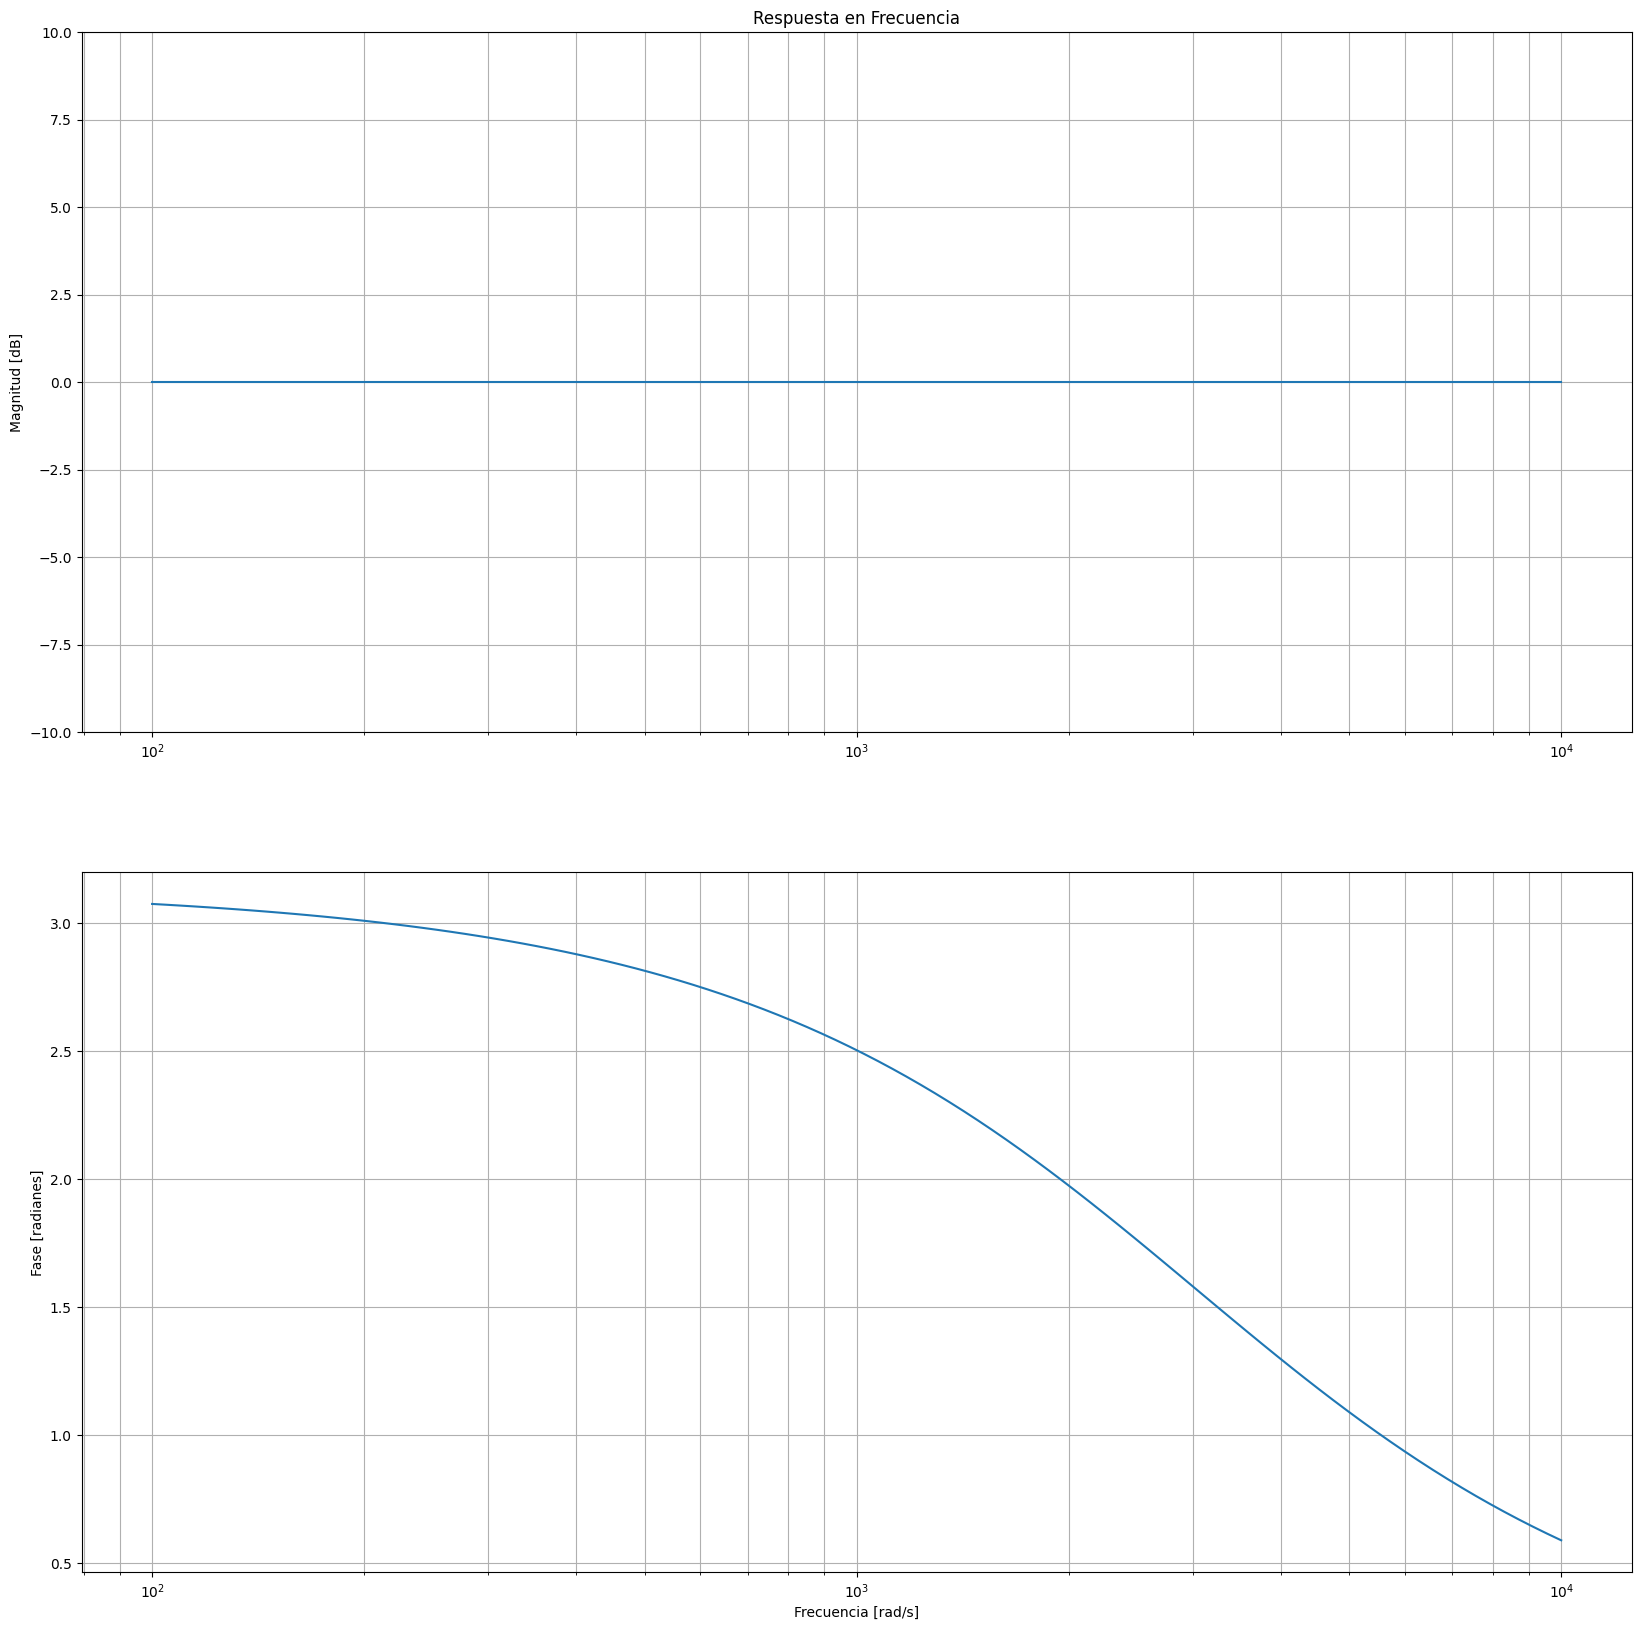

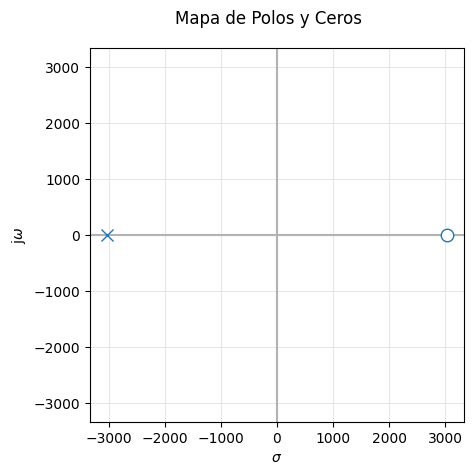

In [3]:
#Caso R1 = R2

R1 = 3300  
R2 = 3300
R3 = 330
C1 = 1e-6
 
num = np.array([ C1 * R3, -R2/R1 ])
den = np.array([ C1 * R3, 1. ])

H1 = sig.lti(num, den)

w, mag, phase = sig.bode(H1)

rad = phase * (np.pi / 180)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

ax1.semilogx(w, mag)
ax1.set_title('Respuesta en Frecuencia')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim(-10, 10)
ax1.grid(True, which="both")

ax2.semilogx(w, rad)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/s]')
ax2.grid(True, which="both")

pzmap(H1)

plt.tight_layout()
plt.show()


### Conclusión: Los resultados coinciden en **general**, en parte debido a que en papel lo hice genérico y en la simulación tuve que asignar valores a los componentes. Por lo que puedo concluir que el Item A está hecho correctamente.

Ahora bien, este análisis fue hecho teniendo en cuenta que $ R_1 = R_2$, tambien hay que considerar los casos $ R_1 > R_2 $ y $ R_1 < R_2 $:

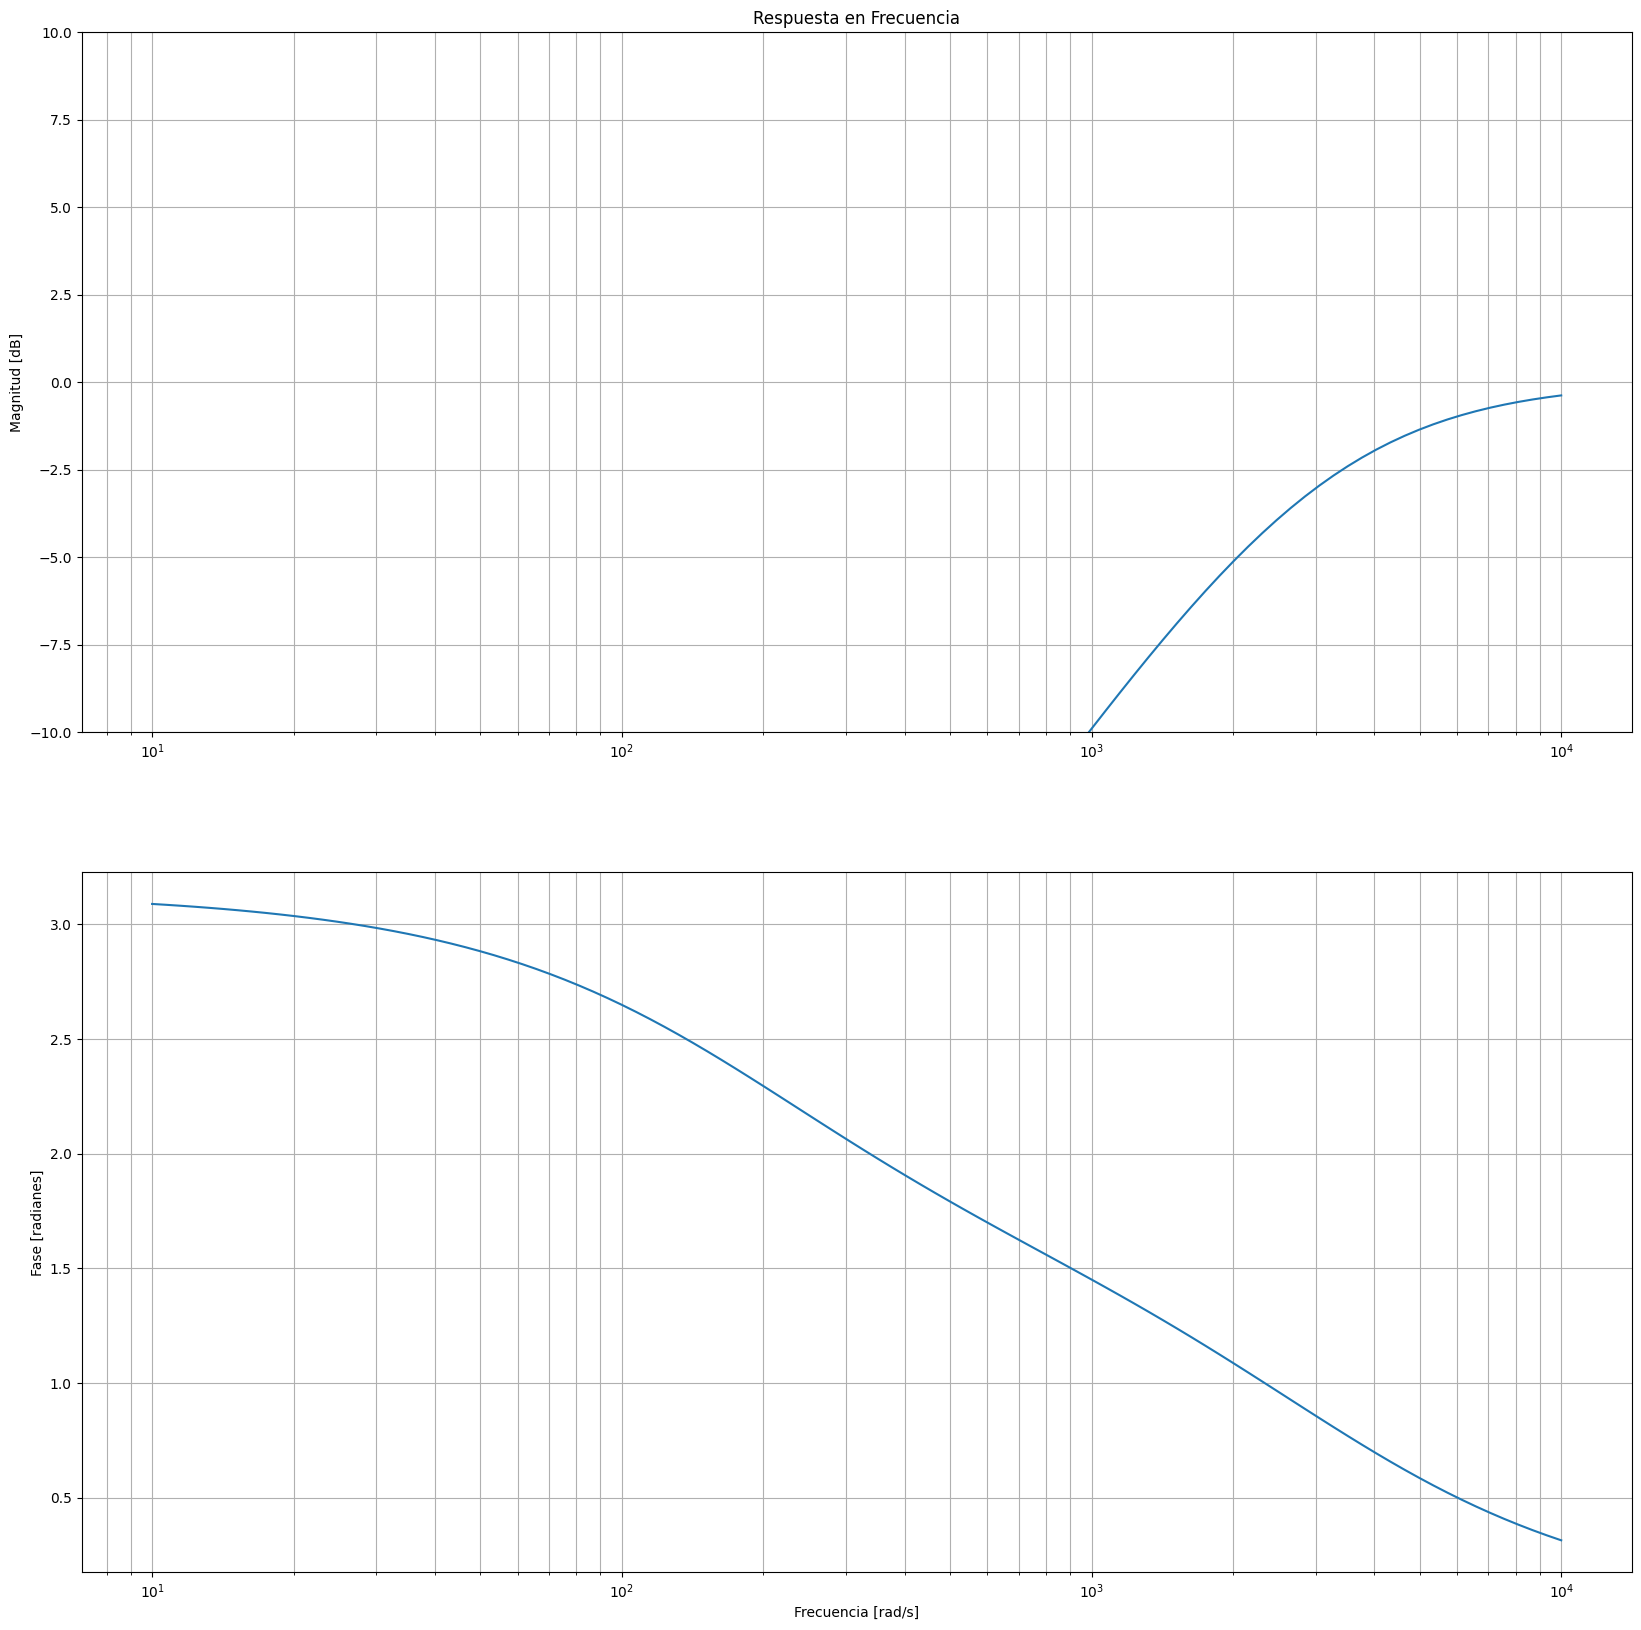

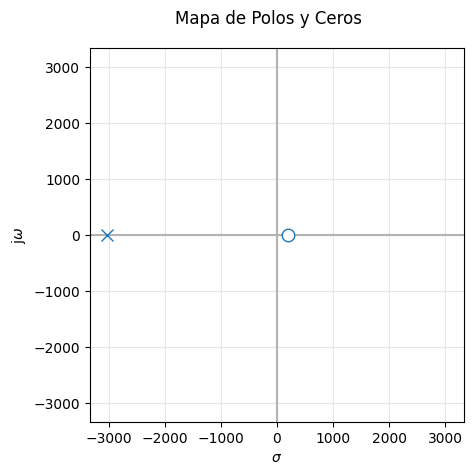

In [4]:
# Caso R1 > R2
R1 = 3300  
R2 = 220
R3 = 330
C1 = 1e-6
 
num = np.array([ C1 * R3, -R2/R1 ])
den = np.array([ C1 * R3, 1. ])

H1 = sig.lti(num, den)

w, mag, phase = sig.bode(H1)

rad = phase * (np.pi / 180)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

ax1.semilogx(w, mag)
ax1.set_title('Respuesta en Frecuencia')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim(-10, 10)
ax1.grid(True, which="both")

ax2.semilogx(w, rad)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/s]')
ax2.grid(True, which="both")

pzmap(H1)

plt.tight_layout()
plt.show()


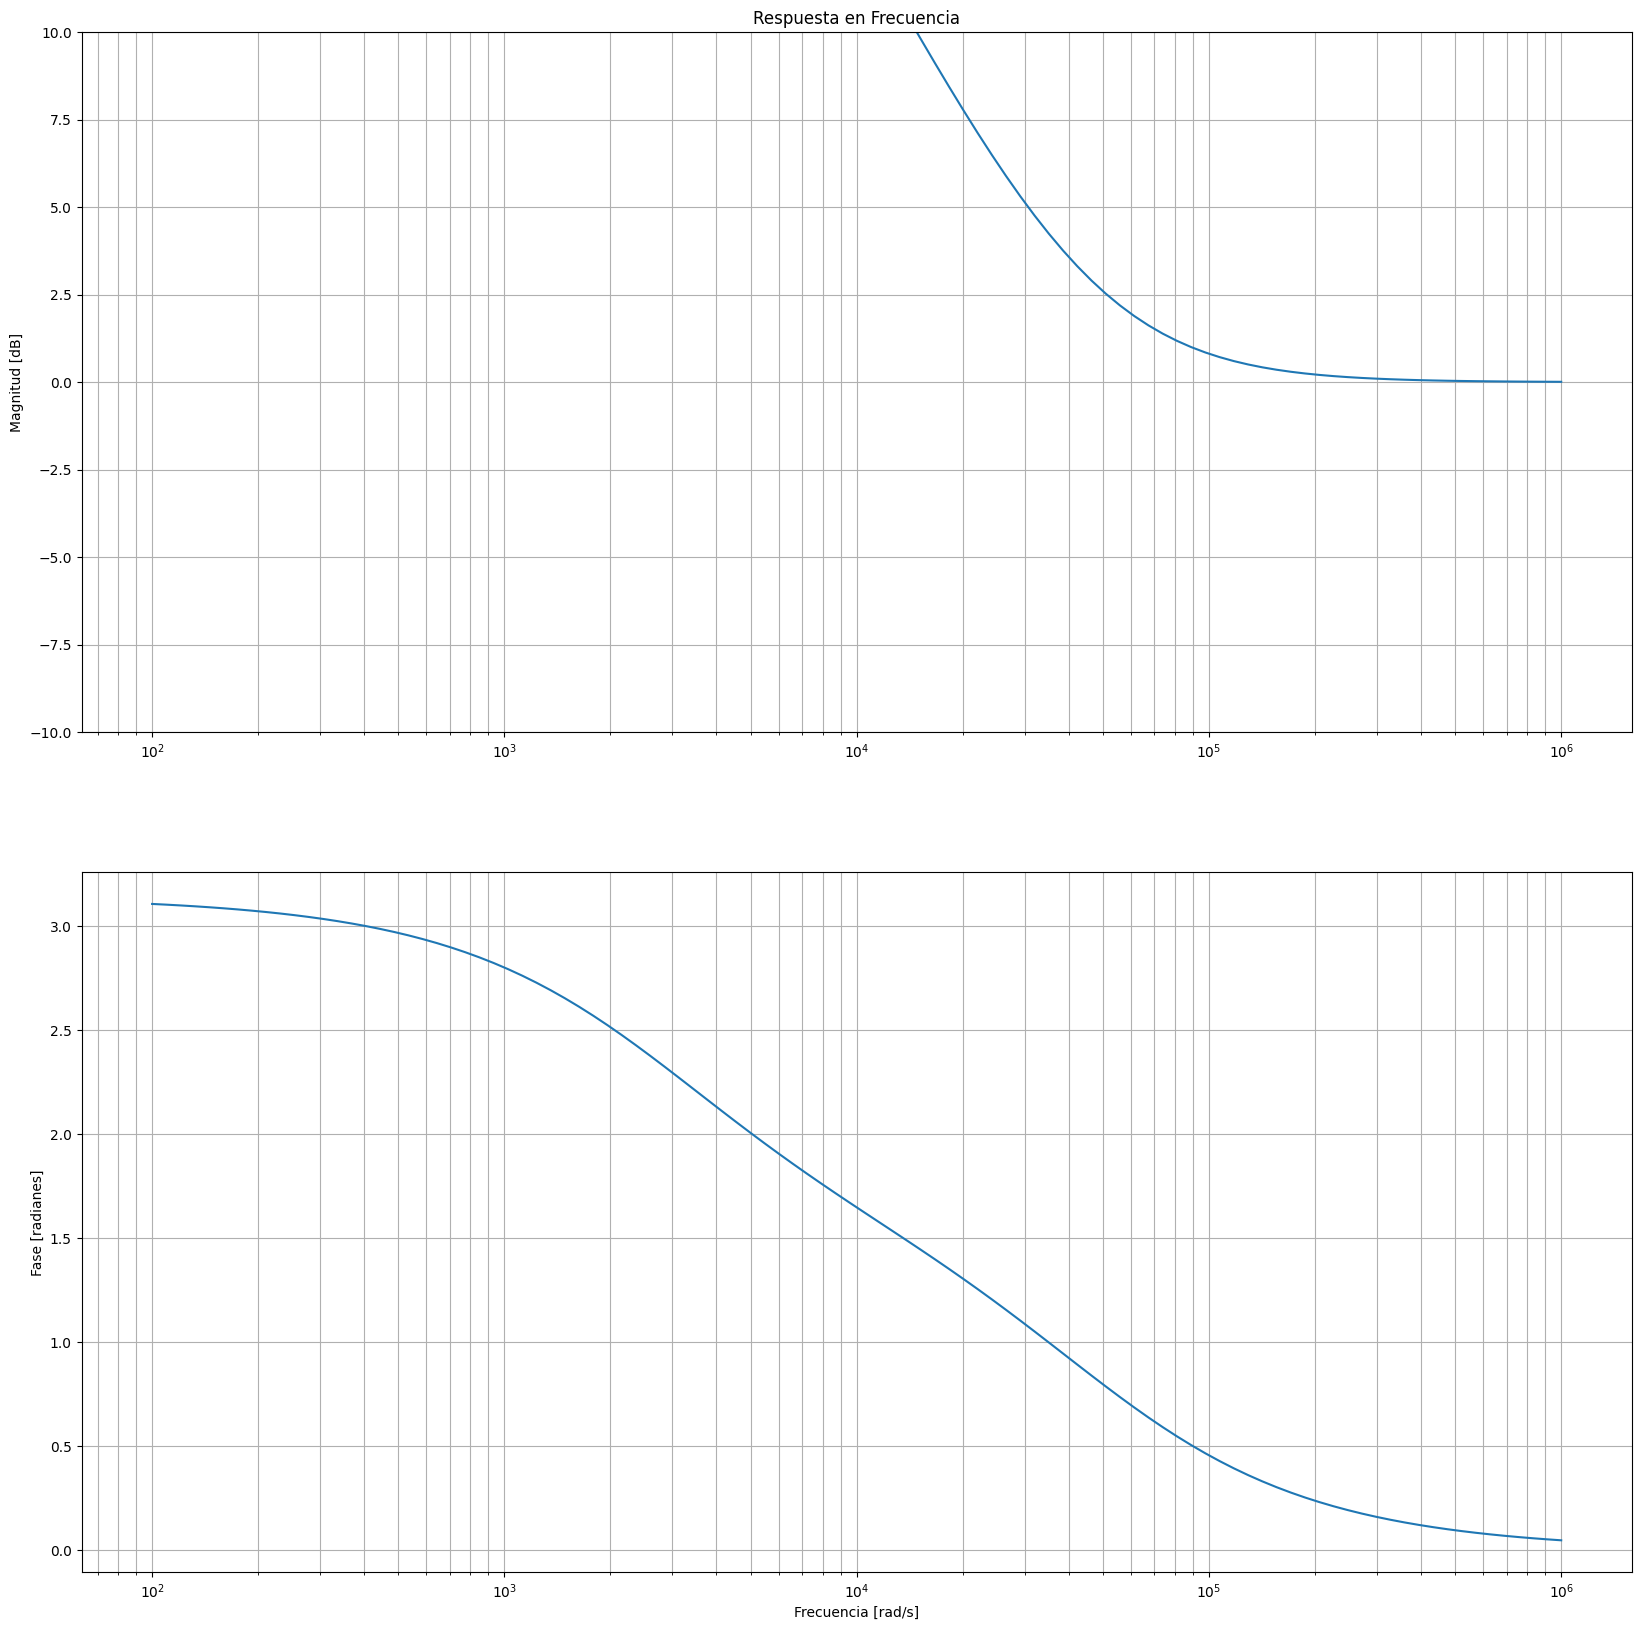

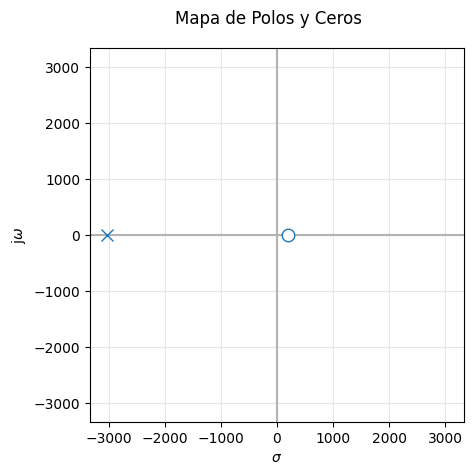

In [5]:
# Caso R1 < R2

R1 = 220  
R2 = 3300
R3 = 330
C1 = 1e-6
 
num = np.array([ C1 * R3, -R2/R1 ])
den = np.array([ C1 * R3, 1. ])

sys = sig.lti(num, den)

w, mag, phase = sig.bode(sys)

rad = phase * (np.pi / 180)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

ax1.semilogx(w, mag)
ax1.set_title('Respuesta en Frecuencia')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim(-10, 10)
ax1.grid(True, which="both")

ax2.semilogx(w, rad)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/s]')
ax2.grid(True, which="both")

pzmap(H1)

plt.tight_layout()
plt.show()

### Conclusión: Si $R_1 > R_2$, estamos hablando de lo que parece ser un filtro pasa alto. En cambio, cuando  $R_1 < R_2$, nos encontramos que el filtro obtiene ganancia tendiendo a infinito en las frecuencias bajas.

## Item 2

Para el Item B, vamos a traer de nuevo la expresión original del Item A:

$$T(s) = \frac{R_2}{R_1} \frac{s C_1 R_3 R_1 - 1}{s C_1 R_3 R_2 + 1}$$

Vamos a reescribir la expresión para observar mejor las componentes:

$$T(s) =  \frac{s - \frac{R_2}{C_1 R_3 R_1}}{s + \frac{1}{C_1 R_3}}$$

Analizando la transferencia podemos concluir que el término $\frac{1}{C_1 R_3}$ es la frecuencia de corte del filtro y a la hora de normalizar por frecuencia queremos que esta se sitúe en $ 1 \frac{rad}{seg} $ por eso:

$$ \Omega_\omega = \omega_o =  \frac{1}{C_1 R_3} $$

Gracias a esto ahora podremos realizar el siguiente cambio de variable:

$$T(ø) = T(s)|_{s = ø \frac{1}{C_1 R_3} } = \frac{ø  \frac{1}{C_1 R_3} - \frac{R_2}{C_1 R_3 R_1}}{ø  \frac{1}{C_1 R_3} + \frac{1}{C_1 R_3}} $$

Operando:

$$T(ø) = T(s)|_{s = ø \frac{1}{C_1 R_3} } = \frac{ø - \frac{R_2}{R_1}}{ø + 1} $$

Luego, podría elegir como $\Omega_Z$ a $R_3$ para que $C_1^{''} = C_1 \ R_3 \ \frac{1}{C_1 R_3} = 1 $ y $R_3^{'} = 1 $

Para $ R_1 = R_2 $ obtengo el mismo $Pasa \ Todo$ 

$$T(ø) = \frac{ø - 1}{ø + 1} $$


## Item 3 

En este Item procederemos a simular las respuestas de los filtros en python.

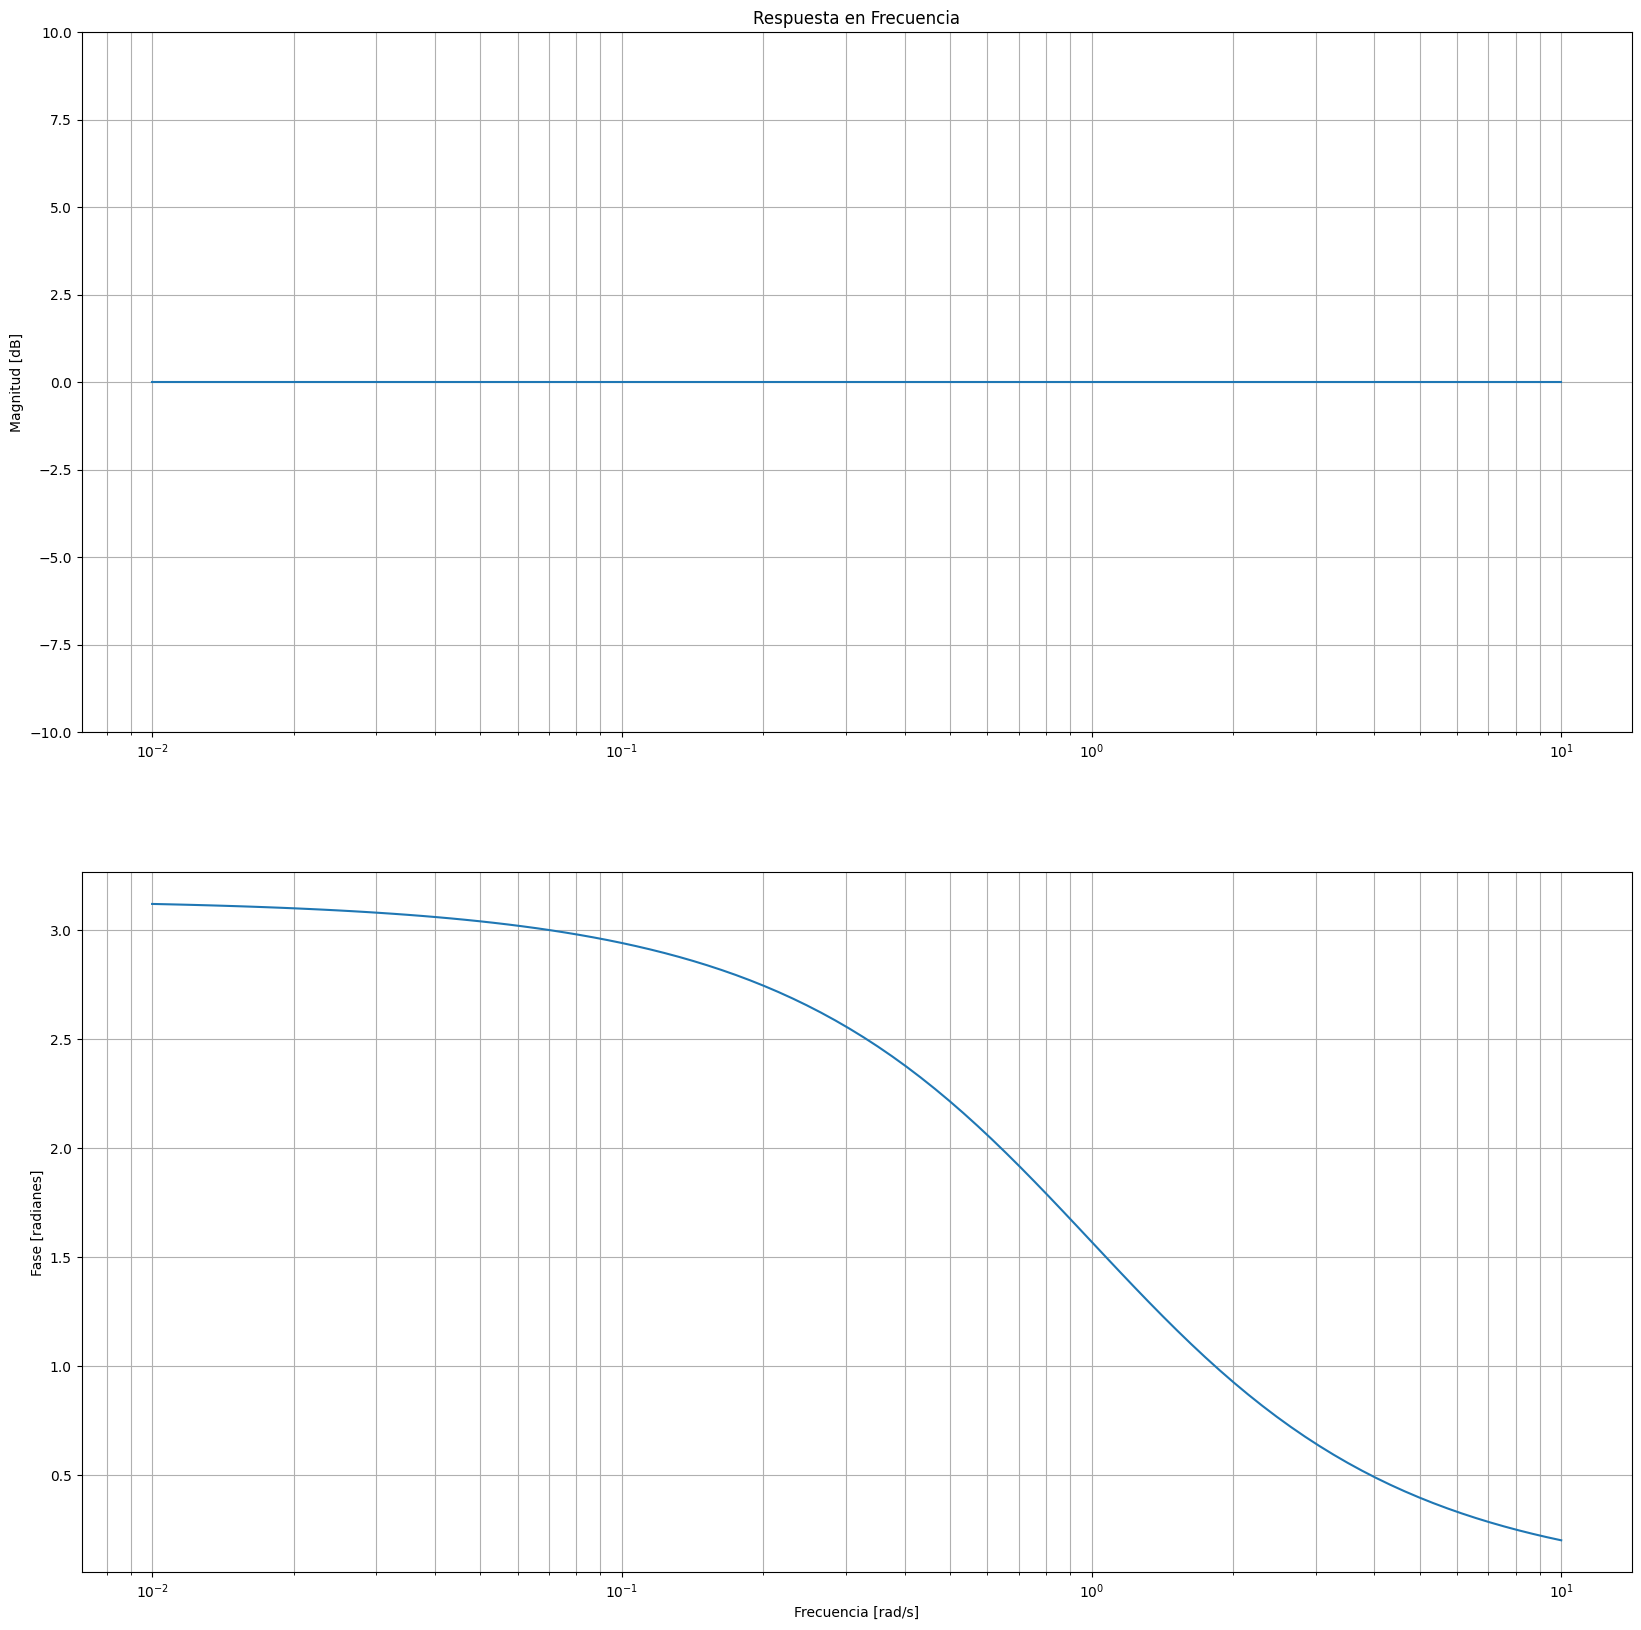

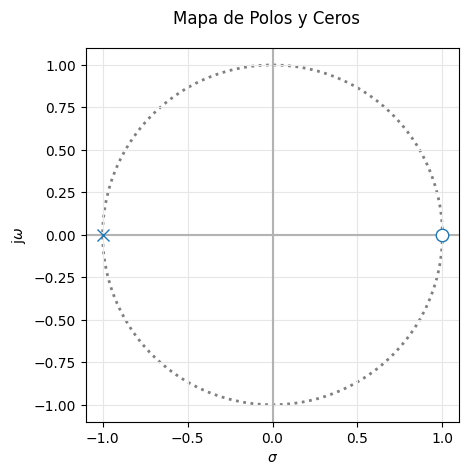

In [6]:
#Caso R1 = R2

R1 = 3300  
R2 = 3300
R3 = 1
C1 = 1
 
num = np.array([ C1 * R3, -R2/R1 ])
den = np.array([ C1 * R3, 1. ])

H1 = sig.lti(num, den)

w, mag, phase = sig.bode(H1)

rad = phase * (np.pi / 180)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

ax1.semilogx(w, mag)
ax1.set_title('Respuesta en Frecuencia')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim(-10, 10)
ax1.grid(True, which="both")

ax2.semilogx(w, rad)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/s]')
ax2.grid(True, which="both")

pzmap(H1)

plt.tight_layout()
plt.show()

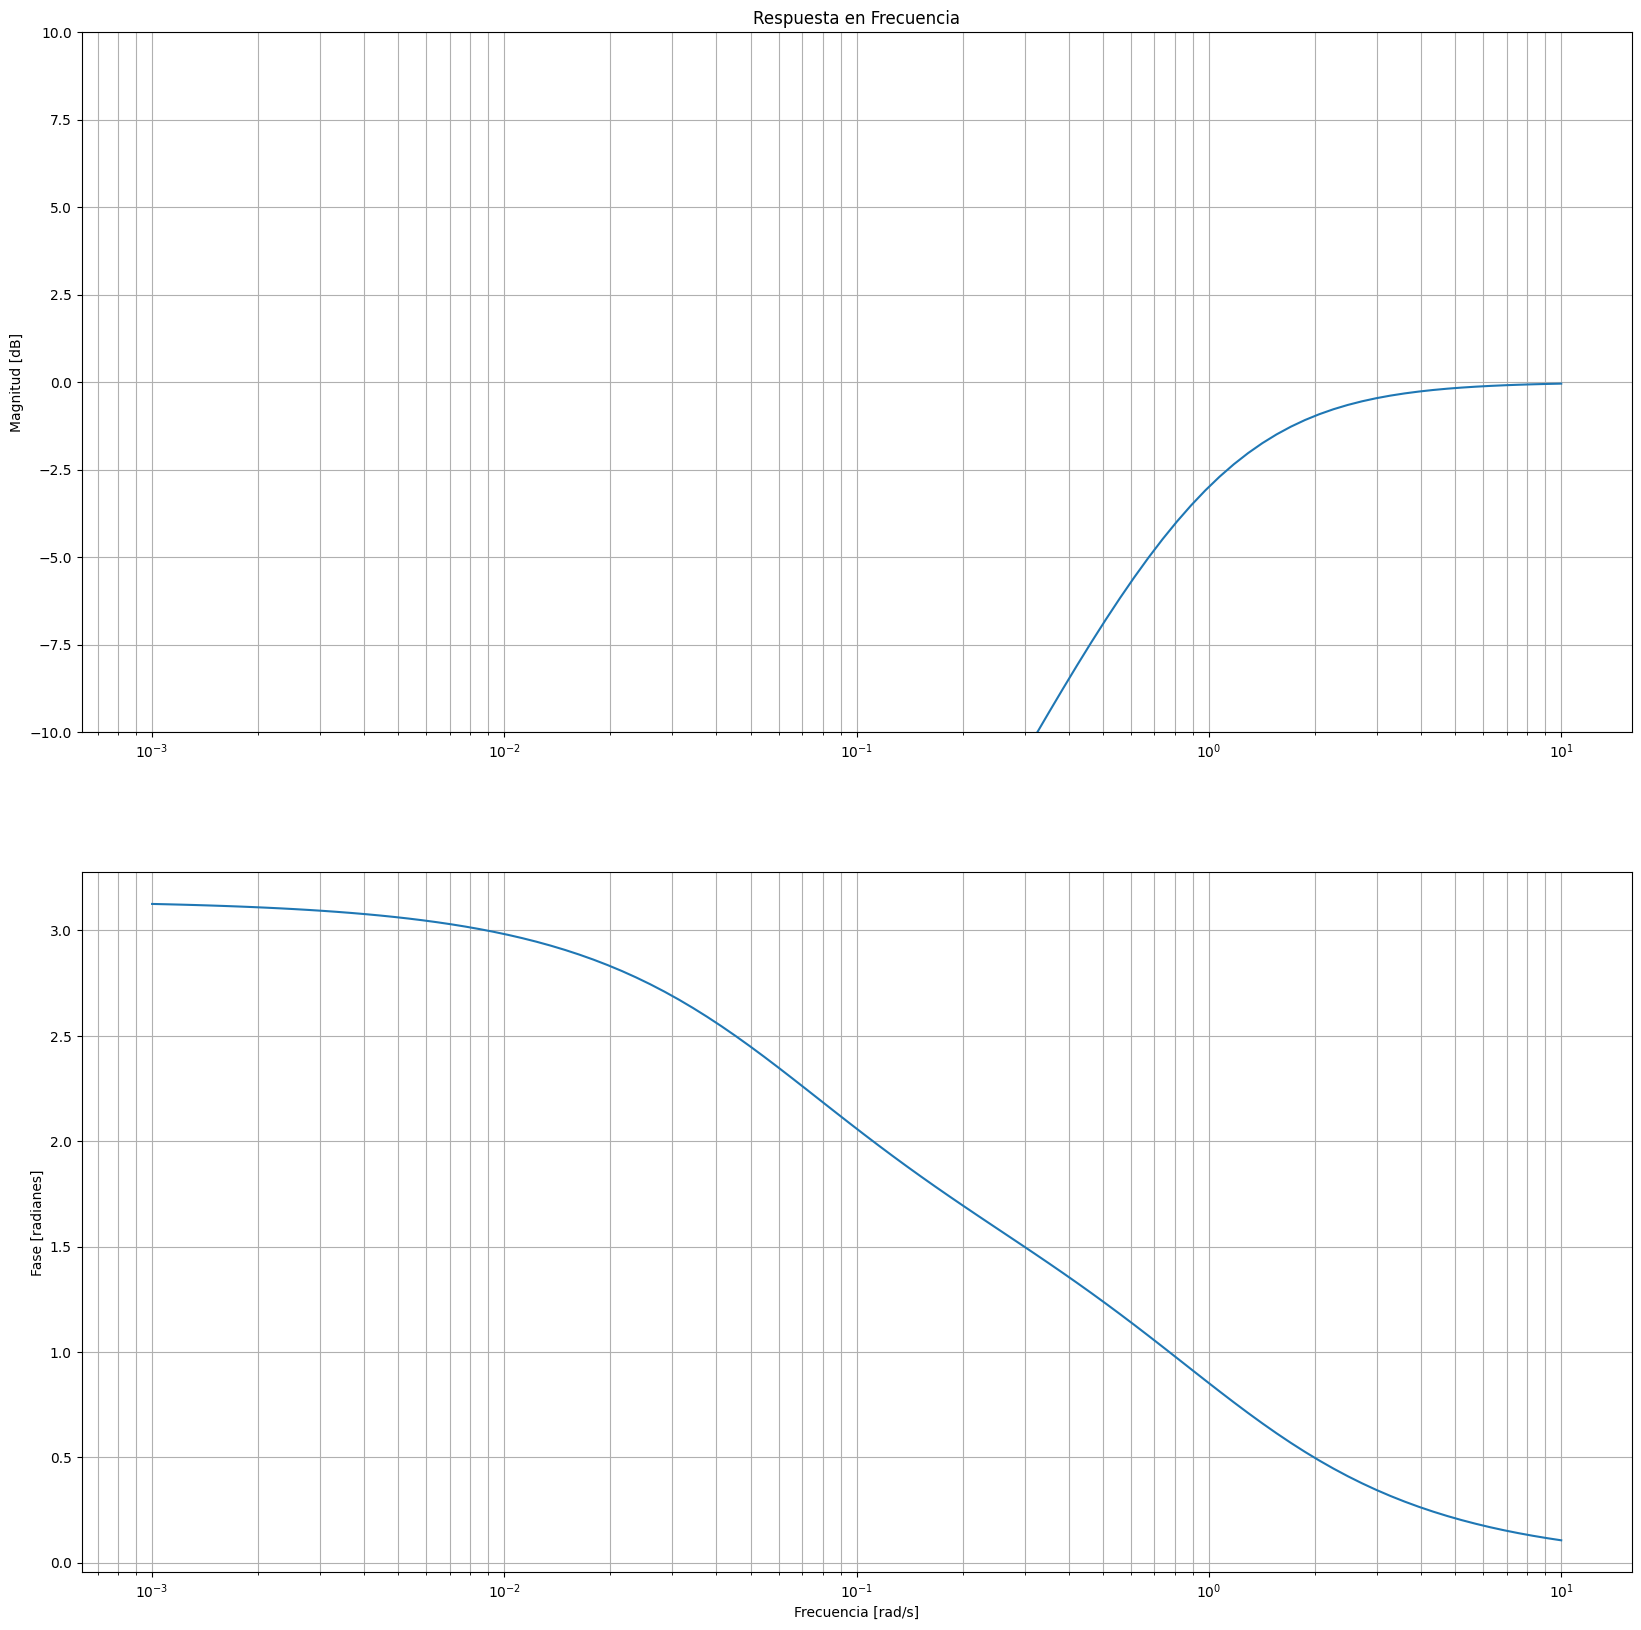

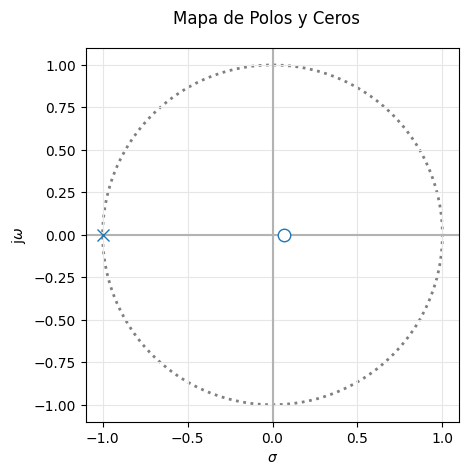

In [7]:
#Caso R1 > R2

R1 = 3300  
R2 = 220
R3 = 1
C1 = 1
 
num = np.array([ C1 * R3, -R2/R1 ])
den = np.array([ C1 * R3, 1. ])

H1 = sig.lti(num, den)

w, mag, phase = sig.bode(H1)

rad = phase * (np.pi / 180)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

ax1.semilogx(w, mag)
ax1.set_title('Respuesta en Frecuencia')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim(-10, 10)
ax1.grid(True, which="both")

ax2.semilogx(w, rad)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/s]')
ax2.grid(True, which="both")

pzmap(H1)

plt.tight_layout()
plt.show()

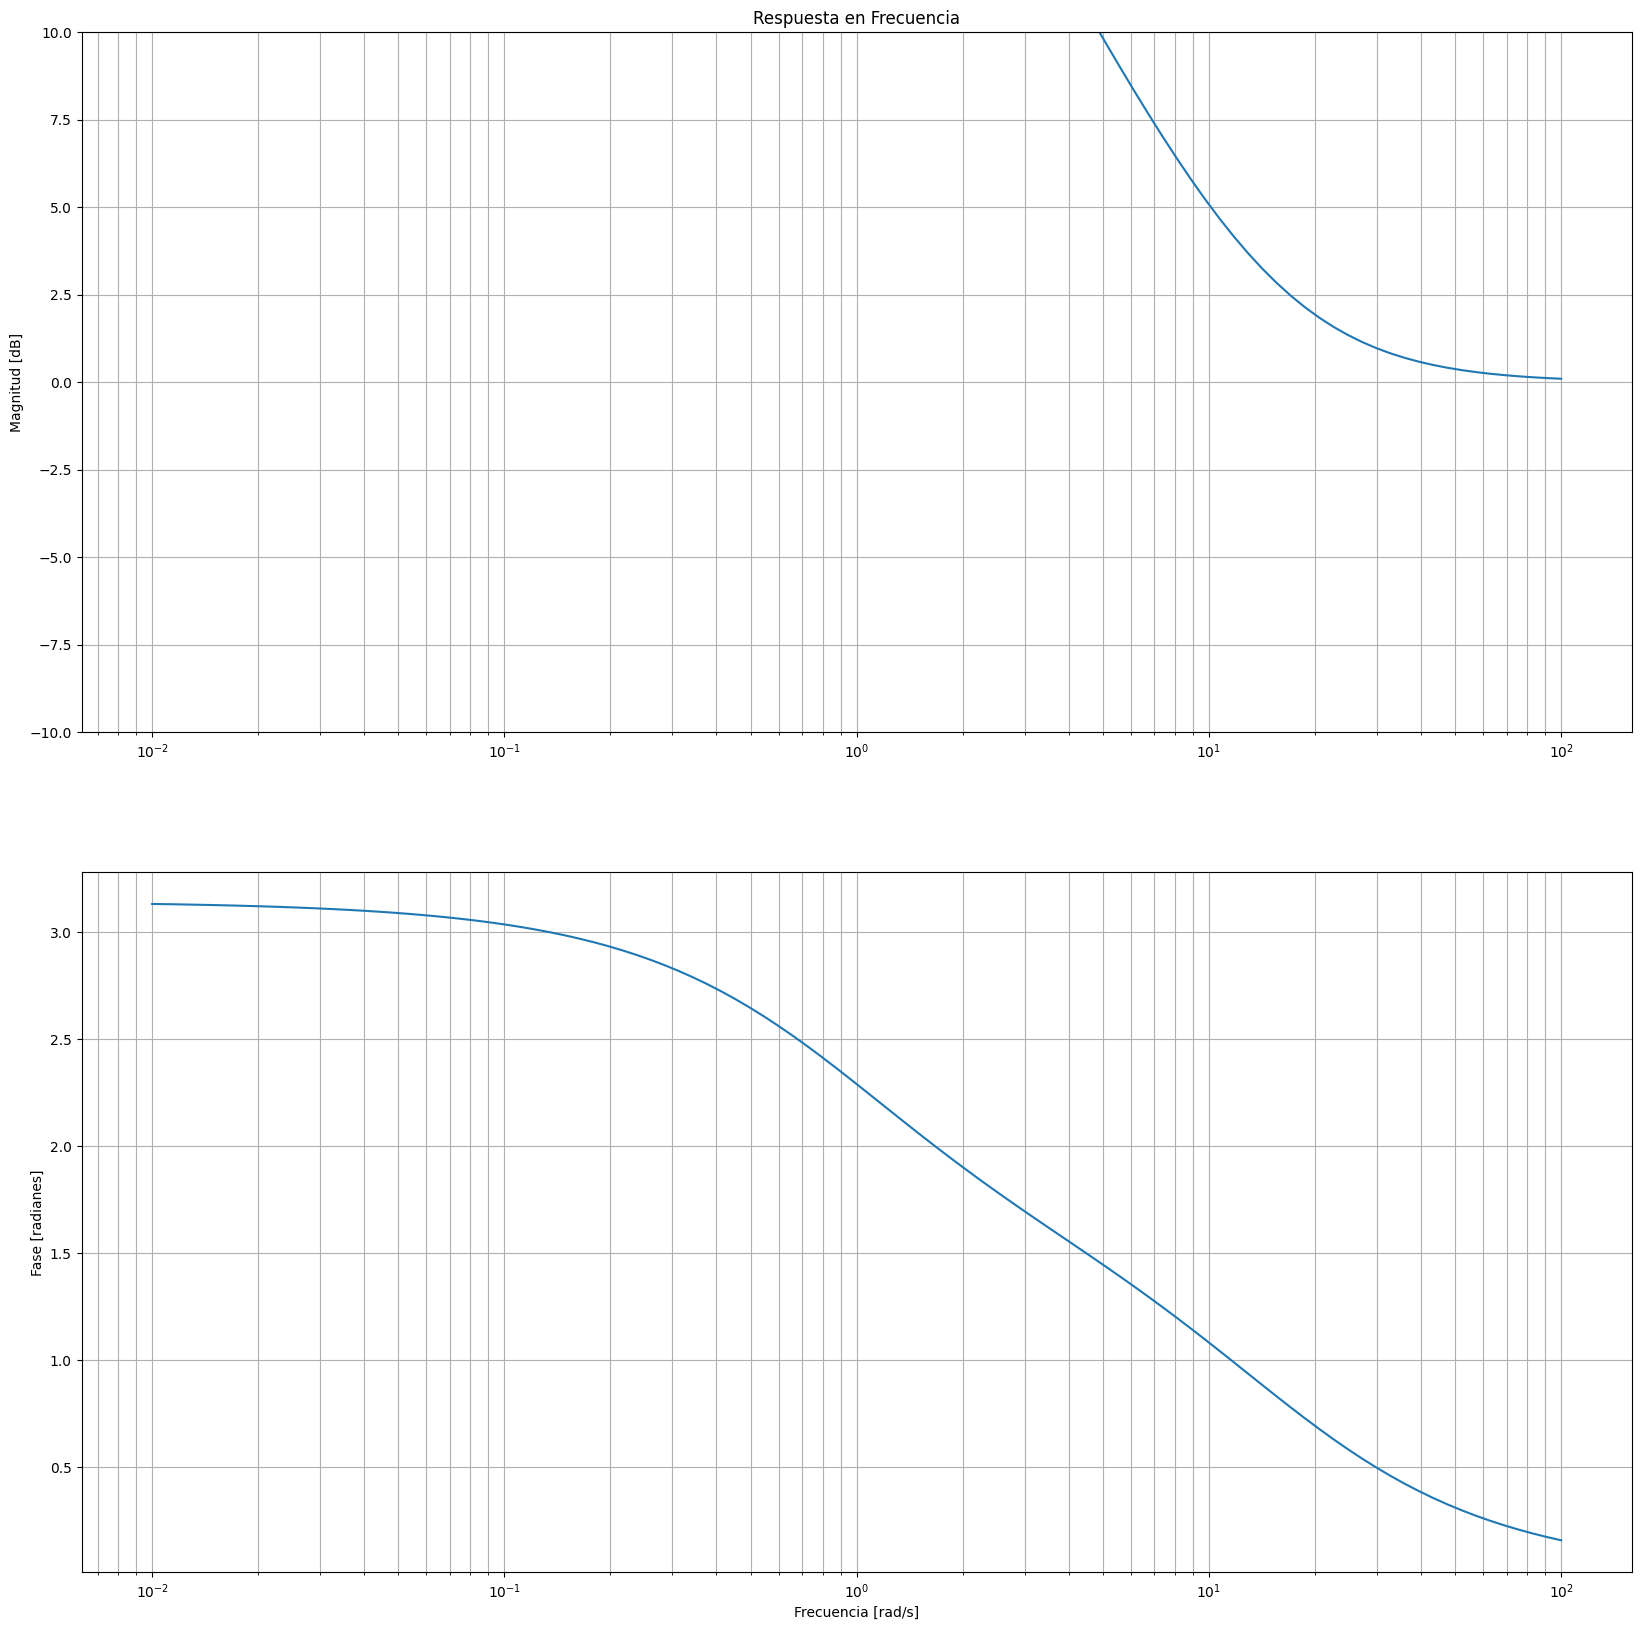

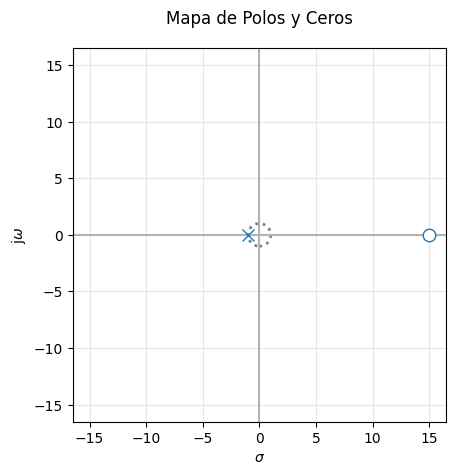

In [8]:
#Caso R1 < R2

R1 = 220  
R2 = 3300
R3 = 1
C1 = 1
 
num = np.array([ C1 * R3, -R2/R1 ])
den = np.array([ C1 * R3, 1. ])

H1 = sig.lti(num, den)

w, mag, phase = sig.bode(H1)

rad = phase * (np.pi / 180)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 20))

ax1.semilogx(w, mag)
ax1.set_title('Respuesta en Frecuencia')
ax1.set_ylabel('Magnitud [dB]')
ax1.set_ylim(-10, 10)
ax1.grid(True, which="both")

ax2.semilogx(w, rad)
ax2.set_ylabel('Fase [radianes]')
ax2.set_xlabel('Frecuencia [rad/s]')
ax2.grid(True, which="both")

pzmap(H1)

plt.tight_layout()
plt.show()

### Conclusión: El polo siempre se mantiene en -1, lo que marca la frecuencia de corte del filtro.

## Item 4 
Para este Item vamos a disponer del circuito en LTspice:

<img src="./esquema.png" align="centre" width="1500" /> 


<img src="./respuestafreq.png" align="centre" width="1000" /> 

En la respuesta en frecuencia vemos que la respuesta en frecuencia ronda los $ 47,5 Hz $. Esto se puede verifica matemáticamente:

$$\omega_o = \frac{1}{C_1 R_3} = \frac{1}{1\mu F \ . \ 3K3 \Omega} \simeq 303.03 \frac{rad}{seg} $$

$$F_o = \frac{\omega_o}{2 \pi} = \frac{303.03 \frac{rad}{seg}}{2 \pi} \simeq 48,28 Hz $$

Como podemos ver, verifica el cálculo analítico y coincide con lo visto en la simulación.

## Item 5

Tomando el caso de $R_1 = R_2$, podemos decir que estamos ante un filtro pasa todo, que actúa como un desfasador (produce un retardo en la fase de la señal). Y en el caso del $MF-103$, que es un pedal de guitarra, este efecto se puede usar para retardar una el audio de la guitarra y generar un efecto de eco generando puntos de cancelación producto de estos retardos en algunas frecuencias y reforzando otras.

<img src="./MF103.png" align="centre" width="1500" /> 

Como se ve en la imagen, hay varias de estas redes intercaladas y un oscilador para mover la posición de los filtros.

## BONUS

A continuación paso a dejar el primer y el último item resueltos (tanto en papel como en pizarra):

<img src="./ResBonus.png" align="centre" width="1000" /> 
<img src="./ResBonusPiz.jpg" align="centre" width="1000" /> 

Luego, pasaremos a simular este filtro:

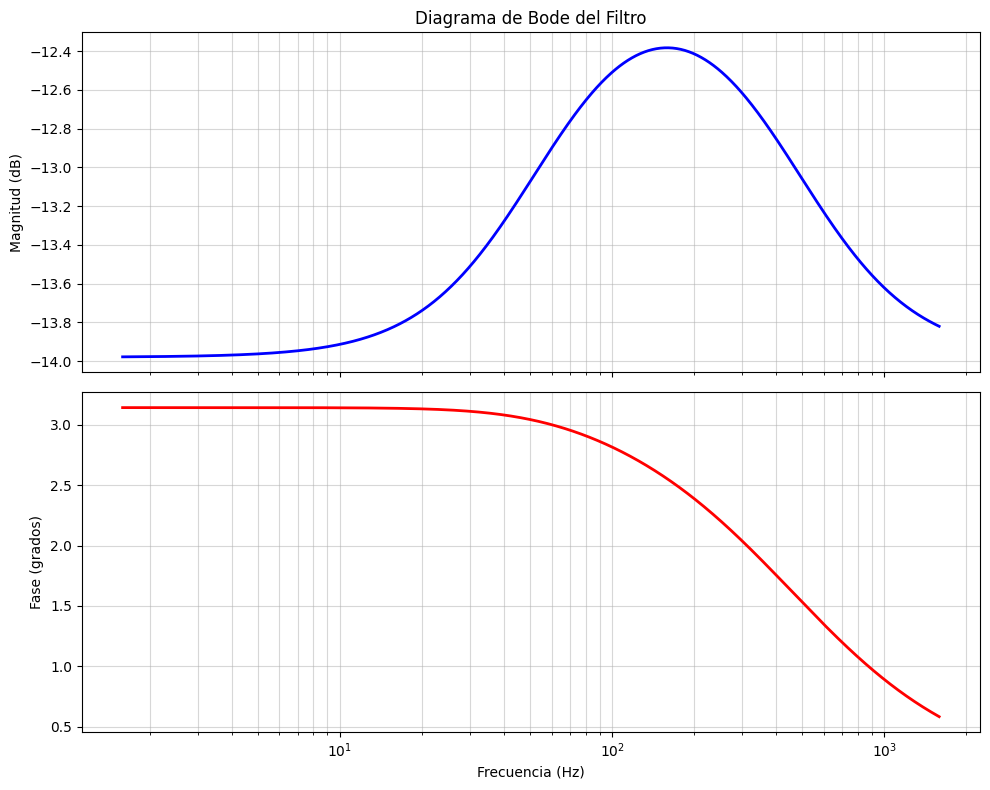

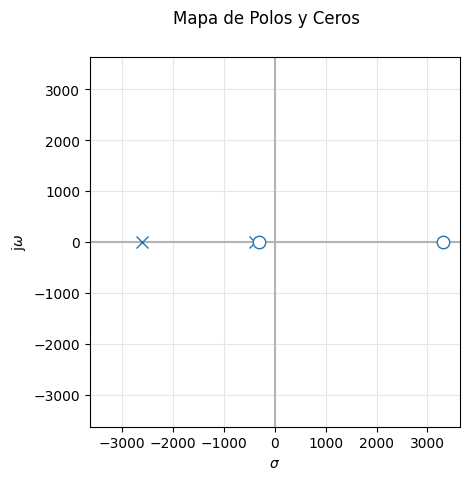

In [9]:
#Filtro ejercicio 7 de la guía de ejercicios

R1 = 5e3
R2 = 1e3
R3 = 1e3
C1 = 1e-6
 
num = np.array([ ( R2/R1 ) * C1**2 * R3**2.  , ( R2/R1 ) * C1 * R3 * (2 - ( R1/R2 ) ) , - ( R2/R1 ) ])
den = np.array([ C1**2 * R3**2, 3 * C1 * R3 , 1. ])

H1 = sig.TransferFunction(num, den)

w, mag, phase = sig.bode(H1, n=1000)
f = w / (2 * np.pi)

rad = phase * ( np.pi / 180 )

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.semilogx(f, mag, color='blue', linewidth=2)
ax1.set_title('Diagrama de Bode del Filtro')
ax1.set_ylabel('Magnitud (dB)')
ax1.grid(True, which="both", ls="-", alpha=0.5)

ax2.semilogx(f, rad, color='red', linewidth=2)
ax2.set_ylabel('Fase (grados)')
ax2.set_xlabel('Frecuencia (Hz)')
ax2.grid(True, which="both", ls="-", alpha=0.5)

plt.tight_layout()
pzmap(H1)
plt.show()



### Conclusión: Este filtro se trata de un Pasa Banda, a diferencia del de la consigna, que se trata de un filtro Pasa Todo

### Simulación simbólica

Para este último inciso vamos a proceder a realizar una simulación del algebra que utilice para resolver el filtro en los incisos $ 1) $ y $ 2) $ 

In [10]:
# Simbolos a utilizar para el análisis simbólico.

V1, V2, Vx = sp.symbols("V1, V2, Vx")
C1, R1, R2, R3, s = sp.symbols("C1, R1, R2, R3, s", real = True, posistive = True) 

Las ecuaciones de Nodo planteadas eran: 

$Nodo \ A:$
$\frac{(V_x - V_1)}{R_1} + \frac{(V_x - V_1)}{R_2} = 0$

$Nodo \ B:$
$\frac{(V_x)}{R_3} + (V_x - V_1) \ sC_1 = 0$

Del nodo B podiamos sacar que: 

$$ V_x = \frac{s C_1 R_3}{s C_1 R_3 + 1} \rightarrow \ divisor \ de \ tensión $$

Entonces, volviendo a Python:

In [11]:
#Planteo el ejercicio a través de la ecuaciones de nodo en formato matricial.

sist = sp.solve([ 
                (Vx-V1)/(R1) + (Vx-V2)/(R2), 
                (Vx)/R3 + (Vx-V1) * s * C1,
                ], 
                [V2, Vx])

T = sist[V2]/V1

Ts = sp.simplify(T) # simplifico el resultado para que parezca una transferencia normal

print_latex(a_equal_b_latex_s('T(s)', Ts)) # imprimo el resultado en LaTeX

<IPython.core.display.Math object>

### Si bien el resultado no esta reducido del todo, se puede ver que haciendo que sacando factor común R1 en el numerador y el denominador, vamos a llegar a la misma expresión del inciso $ 1) $